In [ ]:
import numpy as np
import bilby
import h5py
import matplotlib.pyplot as plt
import tqdm
import plotfancy

ifos = bilby.gw.detector.InterferometerList(['H1', 'L1', 'V1']) 
ifos.set_strain_data_from_zero_noise(
            sampling_frequency=1024.0,
            duration=8.0,
            start_time=1384782888.634277 - 6.,
        )
h_white_waveform = {ifo.name: [] for ifo in ifos}

model = 'SEOBNRv5PHM'
archive = h5py.File('posterior_samples.h5')
posterior = archive.get('C00:'+model)['posterior_samples']


In [ ]:
if model == "SEOBNRv5PHM":
    fd_model = bilby.gw.source.gwsignal_binary_black_hole
    waveform_arguments = {}
elif model == "IMRPhenomXPHM":
    fd_model = bilby.gw.source.lal_binary_black_hole
    waveform_arguments = {'PhenomXHMReleaseVersion': 122022, 'PhenomXPFinalSpinMod': 2, 'PhenomXPrecVersion': 320}
else:
    fd_model = bilby.gw.source.lal_binary_black_hole
    waveform_arguments = {}

waveform_arguments.update(
    {
        "waveform_approximant": model,
        "minimum_frequency": 10,
        "maximum_frequency": 448.0,
        "reference_frequency": 10,
    }
)
waveform_generator = bilby.gw.WaveformGenerator(
    duration=8.0, sampling_frequency=1024.0,
    frequency_domain_source_model=fd_model,
    start_time=1384782888.634277 - 6.,
    waveform_arguments=waveform_arguments
)

parameter_names = posterior.dtype.names
n_samples = len(posterior)
inds = np.arange(n_samples)

for ii in tqdm.tqdm(inds):
    if ii<100:
        params = {key: posterior[key][ii] for key in parameter_names}
        
        pols = waveform_generator.frequency_domain_strain(parameters=params)
        for ifo in ifos:
            h = ifo.get_detector_response(pols, params)
            frequency_window_factor = (
                np.sum(ifo.frequency_mask)
                / len(ifo.frequency_mask)
            )
            ht = h / (ifo.amplitude_spectral_density_array * np.sqrt(ifo.duration / 4))
            h_white_waveform[ifo.name].append(
                np.fft.irfft(ht)
                * np.sqrt(np.sum(ifo.frequency_mask)) / frequency_window_factor
            )


23:55 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.gwsignal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
  1%|          | 112/17939 [00:54<2:25:39,  2.04it/s]


KeyboardInterrupt: 

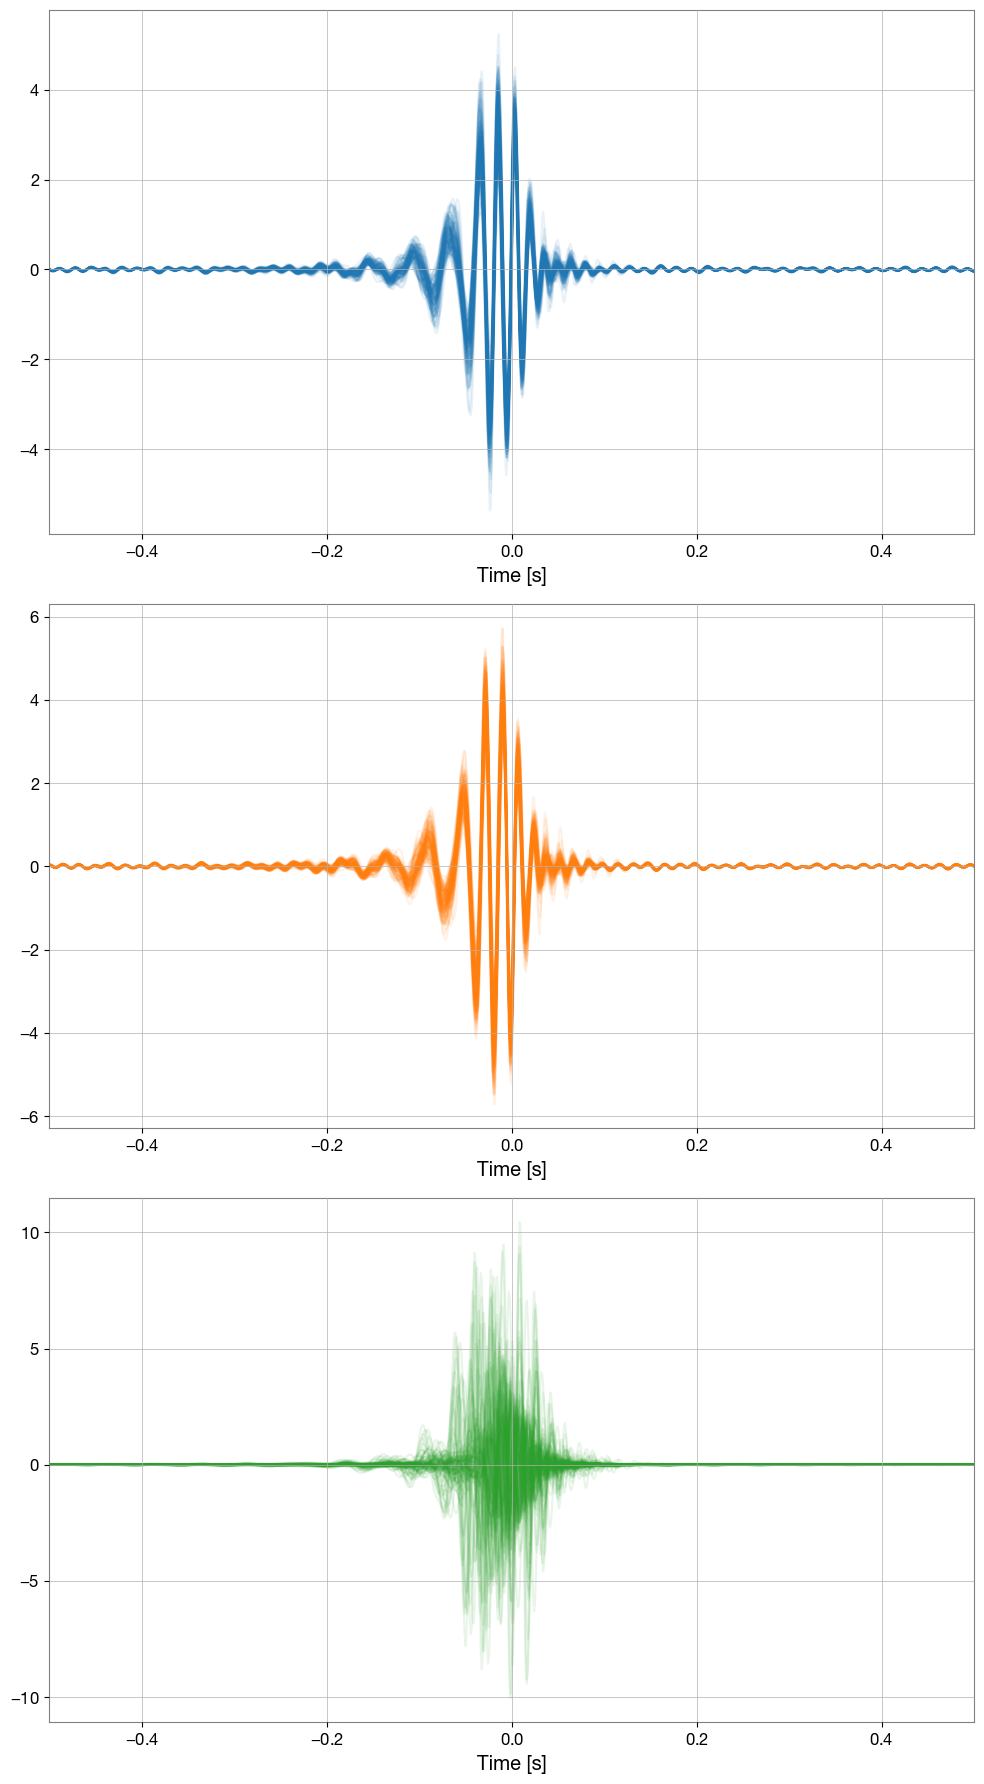

In [6]:
fig = plt.figure(figsize=(10, 18))

ax = plt.subplot(3, 1, 1)
for data in h_white_waveform["H1"]:
    plt.plot(np.linspace(-6, 2, len(data)), data, color="C0", alpha=0.1)
    plt.xlim(-6.0, 2.0)
    plt.xlim(-0.5, 0.5)
    plt.xlabel("Time [s]")

ax = plt.subplot(3, 1, 2)
for data in h_white_waveform["L1"]:
    plt.plot(np.linspace(-6, 2, len(data)), data, color="C1", alpha=0.1)
    plt.xlim(-6.0, 2.0)
    plt.xlim(-0.5, 0.5)
    plt.xlabel("Time [s]")

ax = plt.subplot(3, 1, 3)
for data in h_white_waveform["V1"]:
    plt.plot(np.linspace(-6, 2, len(data)), data, color="C2", alpha=0.1)
    plt.xlim(-6.0, 2.0)
    plt.xlim(-0.5, 0.5)
    plt.xlabel("Time [s]")
plt.tight_layout()

In [46]:
from gwpy.timeseries import TimeSeries
from gwpy.signal import filter_design
hdata = TimeSeries.read("H1_HOFT_C00_BAYESWAVE_S00-1384782888.gwf", "H1:GDS-CALIB_STRAIN_CLEAN_BAYESWAVE_S00")

(-4.0, 4.0)

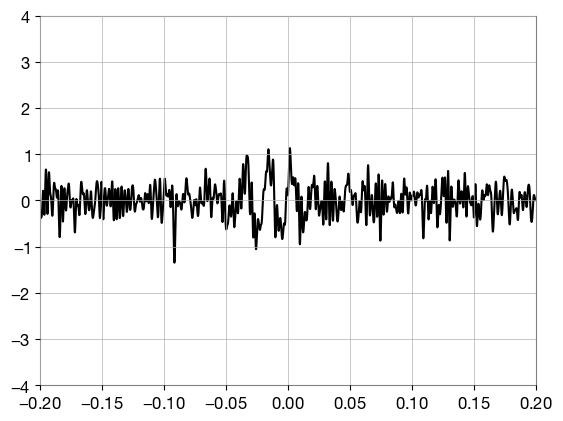

In [82]:
bp = filter_design.bandpass(20, 128, hdata.sample_rate)
notches = [filter_design.notch(line, hdata.sample_rate) for line in (60, 120, 180)]
zpk = filter_design.concatenate_zpks(bp, *notches)
hfilt = hdata.filter(zpk, filtfilt=True)
hfilt = hfilt.whiten()
plt.plot(hfilt.times.value - 1384782888.634277, hfilt.value, color='k')
plt.xlim(-0.2, 0.2)
plt.ylim(-4.0, 4.0)

In [ ]:
hfilt.times.value - hfilt.times[0].value 

array([-6.        , -5.99993896, -5.99987793, ..., 13.99981689,
       13.99987793, 13.99993896], shape=(327680,))

In [63]:
hfilt = hfilt.whiten??

Signature:
hfilt.whiten(
    fftlength=None,
    overlap=0,
    method='median',
    window='hann',
    detrend='constant',
    asd=None,
    fduration=2,
    highpass=None,
    **kwargs,
)
Source:   
    def whiten(self, fftlength=None, overlap=0, method=DEFAULT_FFT_METHOD,
               window='hann', detrend='constant', asd=None,
               fduration=2, highpass=None, **kwargs):
        """Whiten this `TimeSeries` using inverse spectrum truncation

        Parameters
        ----------
        fftlength : `float`, optional
            FFT integration length (in seconds) for ASD estimation,
            default: choose based on sample rate

        overlap : `float`, optional
            number of seconds of overlap between FFTs, defaults to the
            recommended overlap for the given window (if given), or 0

        method : `str`, optional
            FFT-averaging method (default: ``'median'``)

        window : `str`, `numpy.ndarray`, optional
            window functio